In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import matplotlib.patches as patches
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

sns.set_style('ticks', rc={"axes.facecolor": (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams
#rcParams['font.family'] = 'sans-serif'
#rcParams['font.sans-serif'] = ['Arial']

In [22]:
tc = pd.read_csv("../../data/transmission_percentage_combined.tsv", sep="\t")
tc_h = pd.read_csv("../../data/transmission_percentage_combined_h.tsv", sep="\t")
pi = pd.read_csv("../../data/germany_combined_data_counts.tsv", sep="\t")

In [23]:
pi['date'] = pd.to_datetime(pi['date'])
def calculate_monthly_metrics(df):
    df['date'] = pd.to_datetime(df['date'])
    df = df.drop(columns=['period'])
    monthly_metrics = df.groupby(df['date'].dt.to_period('M')).agg({
        'containment_health_index': 'mean',
        'stringency_index': 'mean',
        'movement_data_extended': 'mean',
        'ecoli_count': 'sum',
        'kpneumo_count': 'sum',
        'pseudomonas_count': 'sum'
    }).reset_index()
    monthly_metrics.rename(columns={'date': 'month'}, inplace=True)
    return monthly_metrics

In [24]:
pi_r=calculate_monthly_metrics(pi)

In [25]:
tc_h['month'] = pd.to_datetime(tc_h['month']).dt.to_period('M')
df1_wide = tc_h.pivot(index='month', columns='species', values='transmission_percentage')
df1_wide.columns = [f"transmission_percentage:{col}" for col in df1_wide.columns]
t_npi = pi_r.merge(df1_wide, on='month', how='left')

In [26]:
pandemic_periods = {
    "pre-pandemic": (None, pd.Period("2020-02", freq="M")),
    "acute": (pd.Period("2020-03", freq="M"), pd.Period("2021-02", freq="M")),
    "transition": (pd.Period("2021-03", freq="M"), pd.Period("2022-02", freq="M")),
    "post-pandemic": (pd.Period("2022-03", freq="M"), None)
}

In [27]:
def get_pandemic_period(month):
    if month <= pd.Period("2020-02", freq="M"):
        return "pre-pandemic"
    elif pd.Period("2020-03", freq="M") <= month <= pd.Period("2021-02", freq="M"):
        return "acute"
    elif pd.Period("2021-03", freq="M") <= month <= pd.Period("2022-02", freq="M"):
        return "transition"
    elif month >= pd.Period("2022-03", freq="M"):
        return "post-pandemic"
    else:
        return None

In [28]:
t_npi["pandemic_period"] = t_npi["month"].apply(get_pandemic_period)

In [29]:
from scipy.stats import gaussian_kde
from statsmodels.nonparametric.kde import KDEUnivariate

sns.set_style('ticks', rc={"axes.facecolor": (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']

In [30]:
def plot_ridgeline_transmission(df):
    xkcd_colors = {
        "E. coli": "xkcd:electric blue",
        "K. pneumoniae": "xkcd:orange",
        "P. aeruginosa": "xkcd:royal purple"
    }

    pandemic_periods = {
        "pre-pandemic": (None, pd.Period("2020-02", freq="M")),
        "acute": (pd.Period("2020-03", freq="M"), pd.Period("2021-02", freq="M")),
        "transition": (pd.Period("2021-03", freq="M"), pd.Period("2022-02", freq="M")),
        "post-pandemic": (pd.Period("2022-03", freq="M"), None)
    }

    species_order = ["E. coli", "K. pneumoniae", "P. aeruginosa"]

    df = df.copy()
    df["month_dt"] = df["month"].dt.to_timestamp()
    df = df[df["month_dt"] >= "2019-01"]
    df["month_ord"] = df["month_dt"].map(lambda d: d.toordinal())

    melted = df.melt(
        id_vars=["month_dt", "month_ord"],
        value_vars=[
            "transmission_percentage:E. coli",
            "transmission_percentage:K. pneumoniae",
            "transmission_percentage:P. aeruginosa"
        ],
        var_name="species",
        value_name="transmission_percentage"
    )
    melted["species"] = melted["species"].str.replace("transmission_percentage:", "", regex=False)
    melted.dropna(subset=["transmission_percentage"], inplace=True)

    fig, ax = plt.subplots(figsize=(9, 3))

    for i, species in enumerate(species_order):
        subset = melted[melted["species"] == species]
        x = subset["month_ord"].values
        w = subset["transmission_percentage"].values

        grid = np.linspace(x.min(), x.max(), 500)
        kde = KDEUnivariate(x)
        kde.fit(weights=w, bw=30, fft=False, gridsize=500, cut=0)
        y = kde.evaluate(grid) * 10
        offset = i * 0.08
        grid_dates = [pd.Timestamp.fromordinal(int(xx)) for xx in grid]

        ax.fill_between(grid_dates, y + offset, offset, alpha=0.7, color=xkcd_colors[species], label=species)
        ax.plot(grid_dates, y + offset, color=xkcd_colors[species], lw=1.5)

    # Compute xticks from pandemic_periods midpoints
    xticks = []
    xticklabels = []
    for label, (start, end) in pandemic_periods.items():
        if start is None:
            start_dt = df["month_dt"].min()
        else:
            start_dt = start.to_timestamp()
        if end is None:
            end_dt = df["month_dt"].max()
        else:
            end_dt = end.to_timestamp()

        midpoint = start_dt + (end_dt - start_dt) / 2
        xticks.append(midpoint)
        xticklabels.append(label)

    ax.set_xlim(pd.to_datetime("2019-11"), pd.to_datetime("2023-03"))
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, rotation=0, ha="center")
    ax.set_yticks([i * 0.08 for i in range(len(species_order))])
    ax.set_yticklabels(species_order)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")
    ax.legend(title="Species", facecolor="white")

    plt.tight_layout()
    
    plt.savefig('../../out/figures/transmission_pandemic_h.png',
            dpi=150,
            bbox_inches='tight',
            transparent=True)
    plt.savefig('../../out/figures/transmission_pandemic_h.svg',
            dpi=150, bbox_inches='tight',
            transparent=True);

    plt.show();

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

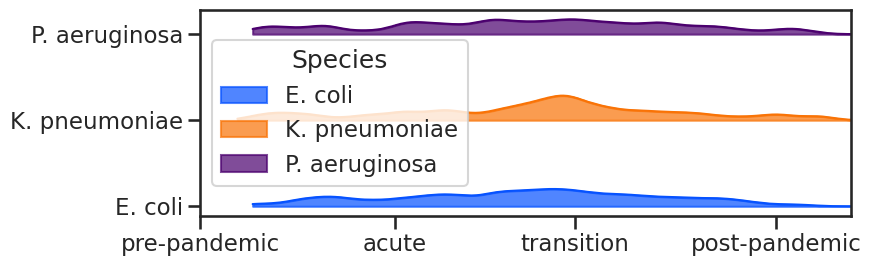

In [31]:
plot_ridgeline_transmission(t_npi)

### test mean transmission per species across pandemic periods

In [32]:
from scipy.stats import kruskal
import scikit_posthocs as sp

In [33]:
def analyze_transmission_by_period(df):
    species_map = {
        "E. coli": "transmission_percentage:E. coli",
        "K. pneumoniae": "transmission_percentage:K. pneumoniae",
        "P. aeruginosa": "transmission_percentage:P. aeruginosa"
    }

    kruskal_results = {}
    posthoc_results = {}

    # Compute means
    mean_df = (
        df.groupby("pandemic_period")[list(species_map.values())]
          .mean()
          .rename(columns={v: k for k, v in species_map.items()})
    )
    print("Mean transmission percentage by pandemic period:")
    print(mean_df.round(2))

    # Prepare melted dataframe for plotting
    melted = df.melt(
        id_vars=["pandemic_period"],
        value_vars=list(species_map.values()),
        var_name="species",
        value_name="transmission_percentage"
    )
    melted["species"] = melted["species"].str.replace("transmission_percentage:", "", regex=False)

    # Loop species: Kruskal + Dunn (if significant)
    for species, col in species_map.items():
        data = df[["pandemic_period", col]].dropna()
        groups = [data[data["pandemic_period"] == p][col] for p in data["pandemic_period"].unique()]
        stat, pval = kruskal(*groups)
        kruskal_results[species] = {"statistic": stat, "pvalue": pval}
        print(f"\nKruskal–Wallis test for {species}: statistic={stat:.2f}, p-value={pval:.4f}")

        if pval < 0.05:
            posthoc = sp.posthoc_dunn(data, val_col=col, group_col="pandemic_period", p_adjust="bonferroni")
            posthoc_results[species] = posthoc.round(4)
            print(f"Dunn post-hoc test for {species} (p-adjusted):")
            print(posthoc_results[species])
        else:
            posthoc_results[species] = None

    # === Plot with significance annotations ===
    g = sns.catplot(
        data=melted,
        x="pandemic_period", y="transmission_percentage", col="species",
        kind="bar", ci="sd", palette="muted", col_wrap=3, sharey=False
    )

    for ax, species in zip(g.axes.flat, species_map.keys()):
        species_data = melted[melted["species"] == species]
        posthoc = posthoc_results[species]

        # Set y-axis limits
        if species == "E. coli":
            ax.set_ylim(0, 30)
            y_max = 30
        elif species == "K. pneumoniae":
            ax.set_ylim(0, 30)
            y_max = 30
        elif species == "P. aeruginosa":
            ax.set_ylim(0, 40)
            y_max = 40

        height_offset = y_max * 0.05

        # Annotations...
        unique_periods = species_data["pandemic_period"].dropna().unique()
        period_pairs = list(combinations(unique_periods, 2))

        for i, (p1, p2) in enumerate(period_pairs):
            x1, x2 = sorted([unique_periods.tolist().index(p1), unique_periods.tolist().index(p2)])
            y = y_max - height_offset * (len(period_pairs) - i)

            if posthoc is not None:
                try:
                    pval = posthoc.loc[p1, p2]
                except KeyError:
                    pval = posthoc.loc[p2, p1]

                if pval < 0.001:
                    label = "p < 0.001"
                elif pval < 0.05:
                    label = f"p = {pval:.3f}"
                else:
                    label = "n.s."
            else:
                label = "n.s."

            ax.plot([x1, x1, x2, x2], [y - 0.01, y, y, y - 0.01], lw=1.2, c='black')
            ax.text((x1 + x2) / 2, y + 0.01, label, ha='center', va='bottom', fontsize=9)

        ax.set_title(species)
        ax.set_ylabel("Transmission %")
        ax.set_xlabel("")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

        if ax.legend_:
            ax.legend_.remove()
        ax.set_facecolor("white")

    plt.tight_layout()
     
    plt.savefig('../../out/figures/transmission_pandemic_h_sig.png',
            dpi=150,
            bbox_inches='tight',
            transparent=True)
    plt.savefig('../../out/figures/transmission_pandemic_h_sig.svg',
            dpi=150, bbox_inches='tight',
            transparent=True);
    
    plt.show()

    return mean_df, kruskal_results, posthoc_results

In [34]:
from itertools import combinations

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

Mean transmission percentage by pandemic period:
                 E. coli  K. pneumoniae  P. aeruginosa
pandemic_period                                       
acute              13.82           8.56          19.38
post-pandemic       5.67           5.27          10.03
pre-pandemic        6.15           7.00          16.70
transition         21.76          19.92          31.07

Kruskal–Wallis test for E. coli: statistic=28.85, p-value=0.0000
Dunn post-hoc test for E. coli (p-adjusted):
                acute  post-pandemic  pre-pandemic  transition
acute          1.0000         0.0404         0.545      0.1424
post-pandemic  0.0404         1.0000         1.000      0.0000
pre-pandemic   0.5450         1.0000         1.000      0.0060
transition     0.1424         0.0000         0.006      1.0000

Kruskal–Wallis test for K. pneumoniae: statistic=20.82, p-value=0.0001
Dunn post-hoc test for K. pneumoniae (p-adjusted):
                acute  post-pandemic  pre-pandemic  transition
acute    

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

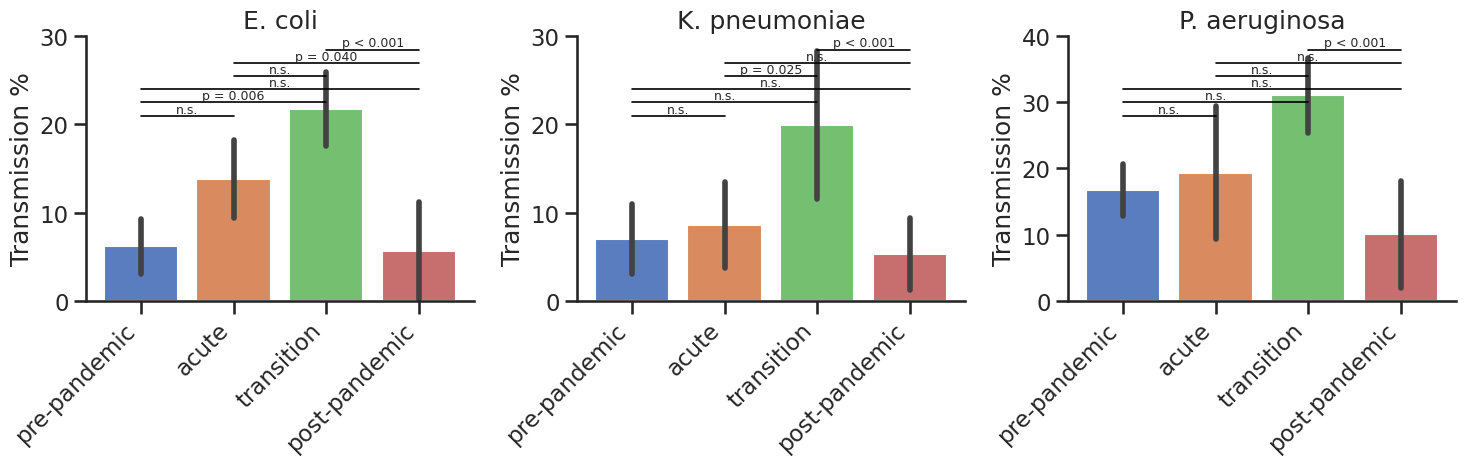

In [35]:
mean_df, kruskal_results, posthoc_results = analyze_transmission_by_period(t_npi)

In [36]:
tekp_h_ = pd.read_csv("../../data/kpneumo/kpneumo_hospital_transmission_vag_amr.csv")
teec_h_= pd.read_csv("../../data/ecoli/ecoli_hospital_transmission_vag_amr.csv")
tepa_h_= pd.read_csv("../../data/paeruginosa/paeruginosa_hospital_transmission_vag_amr.csv")

In [37]:
tekp_h_["month"] = pd.to_datetime(tekp_h_["samplingdate"]).dt.to_period("M").astype(str)
teec_h_["month"] = pd.to_datetime(teec_h_["samplingdate"]).dt.to_period("M").astype(str)
tepa_h_["month"] = pd.to_datetime(tepa_h_["samplingdate"]).dt.to_period("M").astype(str)

In [38]:
tekp_h_["month"] = tekp_h_["month"].astype("period[M]")
teec_h_["month"] = teec_h_["month"].astype("period[M]")
tepa_h_["month"] = tepa_h_["month"].astype("period[M]")

In [39]:
tekp_h_["pandemic_period"] = tekp_h_["month"].apply(get_pandemic_period)
teec_h_["pandemic_period"] = teec_h_["month"].apply(get_pandemic_period)
tepa_h_["pandemic_period"] = tepa_h_["month"].apply(get_pandemic_period)

In [40]:
sns.set_style('ticks', rc={"axes.facecolor": (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']

def plot_transmission_by_vir_res(df, species_name):
    sns.set_theme(style="white", context="talk", font_scale=1.0)

    df = df.copy()
    df["transmission"] = df["transmission_180d"] * 100

    all_periods = ["pre-pandemic", "acute", "transition", "post-pandemic"]
    df["pandemic_period"] = pd.Categorical(df["pandemic_period"], categories=all_periods, ordered=True)

    max_vir = int(df["virulence_score"].max())
    max_res = int(df["resistance_score"].max())

    vir_palette = sns.light_palette("darkred", n_colors=max_vir + 1)
    res_palette = sns.light_palette("darkblue", n_colors=max_res + 1)

    fig, axes = plt.subplots(
        nrows=2, ncols=max(max_vir, max_res) + 1,
        figsize=(3.5 * (max(max_vir, max_res) + 1), 7),
        sharey=False
    )

    # Virulence (top row)
    for score in range(max_vir + 1):
        ax = axes[0, score]
        df_v = df[df["virulence_score"] == score]
        grouped_v = (
            df_v.groupby("pandemic_period")["transmission"]
                .mean()
                .reindex(all_periods)
                .reset_index()
                .fillna(0)
        )
        sns.barplot(data=grouped_v, x="pandemic_period", y="transmission",
                    ax=ax, color=vir_palette[score])
        ax.set_title(f"Virulence = {score}")
        ax.set_ylabel("Transmission %")
        ax.set_ylim(0)
        ax.set_facecolor("white")
        ax.grid(False)
        ax.set_xlabel("")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

    # Resistance (bottom row)
    for score in range(max_res + 1):
        ax = axes[1, score]
        df_r = df[df["resistance_score"] == score]
        grouped_r = (
            df_r.groupby("pandemic_period")["transmission"]
                .mean()
                .reindex(all_periods)
                .reset_index()
                .fillna(0)
        )
        sns.barplot(data=grouped_r, x="pandemic_period", y="transmission",
                    ax=ax, color=res_palette[score])
        ax.set_title(f"Resistance = {score}")
        ax.set_ylabel("Transmission %")
        ax.set_ylim(0)
        ax.set_facecolor("white")
        ax.grid(False)
        ax.set_xlabel("")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

    # Hide unused subplots (if resistance and virulence scores differ)
    n_cols = axes.shape[1]
    for i in range(n_cols):
        if i > max_vir:
            axes[0, i].set_visible(False)
        if i > max_res:
            axes[1, i].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"../../out/figures/{species_name}_transmission_by_vir_res.png", dpi=150, bbox_inches="tight", transparent=True)
    plt.savefig(f"../../out/figures/{species_name}_transmission_by_vir_res.svg", dpi=150, bbox_inches="tight", transparent=True)
    plt.show();

In [93]:
def plot_transmission_by_vir_res_new(df, species_name, title=""):
    sns.set_theme(style="white", context="talk", font_scale=1.0)

    df = df.copy()
    df["transmission"] = df["transmission_180d"] * 100

    all_periods = ["pre-pandemic", "acute", "transition", "post-pandemic"]
    df["pandemic_period"] = pd.Categorical(df["pandemic_period"], categories=all_periods, ordered=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    # --- Virulence plot ---
    df["virulence_score_str"] = df["virulence_score"].astype(str)
    vir_palette = sns.color_palette("Reds", as_cmap=False, n_colors=df["virulence_score"].nunique())
    vir_plot_data = (
        df.groupby(["pandemic_period", "virulence_score_str"])["transmission"]
          .mean()
          .reset_index()
          .fillna(0)
    )
    sns.barplot(
        data=vir_plot_data,
        x="pandemic_period", y="transmission", hue="virulence_score_str",
        palette=vir_palette, ax=axes[0]
    )
    axes[0].set_title("Transmission by Virulence Score")
    axes[0].set_ylabel("Transmission %")
    axes[0].set_xlabel("")
    axes[0].set_facecolor("white")
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].legend(title="Virulence", facecolor="white")

    # --- Resistance plot ---
    df["resistance_score_str"] = df["resistance_score"].astype(str)
    res_palette = sns.color_palette("Blues", as_cmap=False, n_colors=df["resistance_score"].nunique())
    res_plot_data = (
        df.groupby(["pandemic_period", "resistance_score_str"])["transmission"]
          .mean()
          .reset_index()
          .fillna(0)
    )
    sns.barplot(
        data=res_plot_data,
        x="pandemic_period", y="transmission", hue="resistance_score_str",
        palette=res_palette, ax=axes[1]
    )
    axes[1].set_title(f"{title}")
    axes[1].set_ylabel("")
    axes[1].set_xlabel("")
    axes[1].set_facecolor("white")
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].legend(title="Resistance", facecolor="white")

    plt.tight_layout()
    plt.savefig(f"../../out/figures/{species_name}_transmission_by_vir_res.png", dpi=150, bbox_inches="tight", transparent=True)
    plt.savefig(f"../../out/figures/{species_name}_transmission_by_vir_res.svg", dpi=150, bbox_inches="tight", transparent=True)
    plt.show();

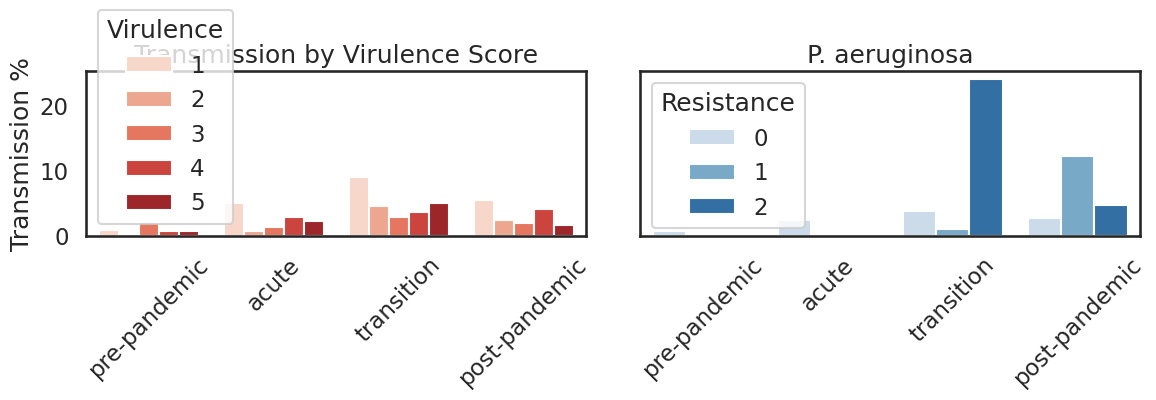

In [94]:
plot_transmission_by_vir_res_new(tepa_h_, species_name="pa", title="P. aeruginosa")

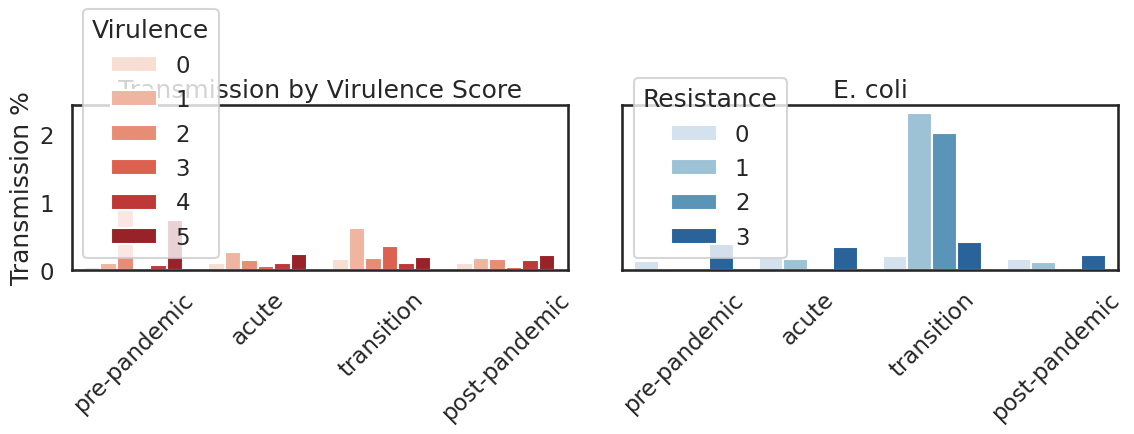

In [95]:
plot_transmission_by_vir_res_new(teec_h_, species_name="ec", title="E. coli")

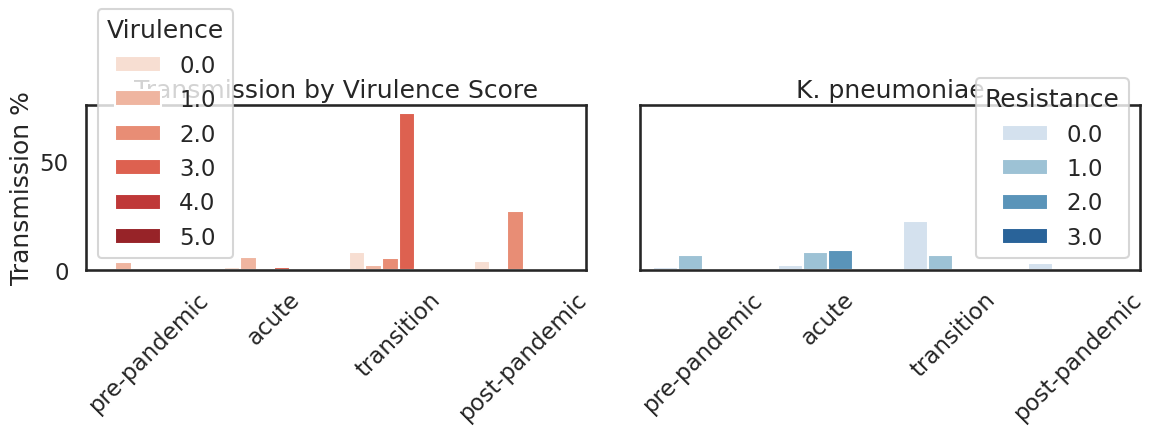

In [96]:
plot_transmission_by_vir_res_new(tekp_h_, species_name="kp", title="K. pneumoniae")